# Multiclass Model Review — Validation Template

Loads a single **SELL / FLAT / BUY** multiclass model pack, runs the full preprocessing
pipeline on a held-out OHLCV dataset, applies trade-gating logic, and produces a detailed
P&L breakdown.

**To use this notebook:**
1. Update the model pack path and dataset path in the **Configuration** cell
2. Adjust gating thresholds and fee settings as needed
3. Run all cells sequentially

| Stage | Description |
|---|---|
| Model Load | Unpacks multiclass model pack; displays architecture & training metadata |
| Data Load | Loads validation-period OHLCV; adds features & scales using saved pipeline |
| Predictions | Batched softmax sweep — each bar produces `[sell_prob, flat_prob, buy_prob]` |
| Gating | Regime filter + breakout confirmation |
| P&L | Per-trade outcome simulation with fees; equity curve + drawdown |
| Insights | Threshold sweep, calibration, gating effectiveness |

In [1]:
import os, pickle, types, warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display
warnings.filterwarnings('ignore')

In [ ]:
PACK_PATH  = '../Engine/Model Packs/US500_1minute_TCN_Multiclass_512seq_20260310_fastma_very_selective_model.pkl'  # <-- update path

DS_NAME    = '../data/US500_1minute.csv'
EVAL_START = '2026-01-01'   # Start of evaluation window (None = full file)
EVAL_END   = None           # End of evaluation window   (None = full file)

BUY_THRESHOLD  = 0.5   # Minimum buy_prob  (softmax class 2) to emit BUY
SELL_THRESHOLD = 0.5   # Minimum sell_prob (softmax class 0) to emit SELL

GATE_REGIME   = True    # Mask signals that oppose the current market regime
GATE_BREAKOUT = True    # Require following bar to confirm breakout
GATE_DONCHIAN = True    # Require Donchian trend to confirm direction

TRADING_HOURS = None    # e.g. ('07:00', '20:00') to gate by session

COMMISSION_USD  = 0.0
LOT_SIZE        = 1.0
PIP_VALUE_USD   = 10.0
PIP_SIZE        = 0.0001

PRED_BATCH = 256

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

Device: cuda


## Load Model Pack

In [3]:
def _load_pack(path: str) -> dict:
    with open(path, 'rb') as f:
        return pickle.load(f)

def _build_model(pack: dict) -> torch.nn.Module:
    """Instantiate model from pack — falls back to embedded source if Models.py has changed."""
    model_params = pack['model_params']
    try:
        from Learn.Models import (
            LSTMAttentionSEClassifier, LSTMClassifier,
            TCNAttentionSEClassifier, TransformerSEClassifier,
            TransformerClassifier, HybridLSTMTransformer,
        )
        model_type = str(pack.get('model_info', {}).get('model_type', ''))
        if   'TCN'           in model_type: cls = TCNAttentionSEClassifier
        elif 'TransformerSE' in model_type: cls = TransformerSEClassifier
        elif 'Hybrid'        in model_type: cls = HybridLSTMTransformer
        elif 'Transformer'   in model_type: cls = TransformerClassifier
        elif 'LSTM'          in model_type: cls = LSTMAttentionSEClassifier
        else:                               cls = LSTMClassifier
        source = 'current Models.py'
    except Exception:
        module = types.ModuleType('frozen_model')
        exec(pack['model_class_source'], module.__dict__)
        cls    = getattr(module, pack['model_class'].__name__)
        source = 'embedded source snapshot'

    model = cls(**model_params)
    model.load_state_dict(pack['model'])
    model.eval()
    return model, source

print("Loading model pack...")
pack  = _load_pack(PACK_PATH)
model, source = _build_model(pack)
model = model.to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"  Model loaded ({source}) | params: {n_params:,}")
print(f"  Task: {pack.get('model_info', {}).get('task', 'unknown')} | "
      f"Classes: {pack.get('model_info', {}).get('class_map', {0:'SELL',1:'FLAT',2:'BUY'})}")

Loading model pack...
  Model loaded (current Models.py) | params: 2,283,711
  Task: multiclass | Classes: {0: 'SELL', 1: 'FLAT', 2: 'BUY'}


In [4]:
def _display_pack_info(pack: dict):
    info    = pack.get('model_info', {})
    metrics = pack.get('val_metrics', {})
    params  = pack.get('model_params', {})
    split   = pack.get('data_split', {})

    rows = {
        '-- Training --':  '',
        'Dataset':         info.get('dataset_name', '-'),
        'Date trained':    info.get('date_trained', '-'),
        'Task':            f"{info.get('task','-')} | {info.get('class_map', {0:'SELL',1:'FLAT',2:'BUY'})}",
        'Epochs':          info.get('n_epochs', '-'),
        'Train rows':      f"{split.get('train_rows','-'):,}" if isinstance(split.get('train_rows'), int) else '-',
        'Val rows':        f"{split.get('val_rows','-'):,}"   if isinstance(split.get('val_rows'),   int) else '-',
        'Val start':       split.get('test_start_date', '-'),
        'Torch version':   pack.get('torch_version', '-'),
        '-- Architecture --': '',
        'Seq len':         info.get('seq_len', '-'),
        'Input features':  pack.get('feature_count', '-'),
        **{k: v for k, v in params.items()},
        '-- Validation Metrics --': '',
        'Final F1 SELL':        f"{metrics.get('final_f1_sell', 0):.4f}"        if metrics else '-',
        'Final F1 BUY':         f"{metrics.get('final_f1_buy',  0):.4f}"        if metrics else '-',
        'Final Prec SELL':      f"{metrics.get('final_precision_sell', 0):.4f}" if metrics else '-',
        'Final Prec BUY':       f"{metrics.get('final_precision_buy',  0):.4f}" if metrics else '-',
        'Final Recall SELL':    f"{metrics.get('final_recall_sell', 0):.4f}"    if metrics else '-',
        'Final Recall BUY':     f"{metrics.get('final_recall_buy',  0):.4f}"    if metrics else '-',
        'Final Val Profit':     f"{metrics.get('final_profit', 0):.2f}"         if metrics else '-',
    }

    print(f"\n{'='*52}")
    print("  MULTICLASS MODEL")
    print(f"{'='*52}")
    for field, value in rows.items():
        if '--' in str(field):
            print(f"  {field}")
        else:
            print(f"  {field:<24} {value}")

_display_pack_info(pack)


  MULTICLASS MODEL
  -- Training --
  Dataset                  US500_1minute
  Date trained             20260310
  Task                     multiclass | {0: 'SELL', 1: 'FLAT', 2: 'BUY'}
  Epochs                   30
  Train rows               2,837,540
  Val rows                 315,365
  Val start                2026-01-01
  Torch version            2.10.0+cu130
  -- Architecture --
  Seq len                  512
  Input features           89
  input_dim                89
  hidden_channels          224
  num_layers               7
  kernel_size              3
  num_classes              3
  dropout                  0.2
  dropout_out              0.4
  attn_heads               8
  attn_dropout             0.1
  use_learned_query        True
  bias_init                [-3.877860802479641, -0.04383175286453496, -3.808113291495351]
  -- Validation Metrics --
  Final F1 SELL            0.2175
  Final F1 BUY             0.1880
  Final Prec SELL          0.4551
  Final Prec BUY           0.4

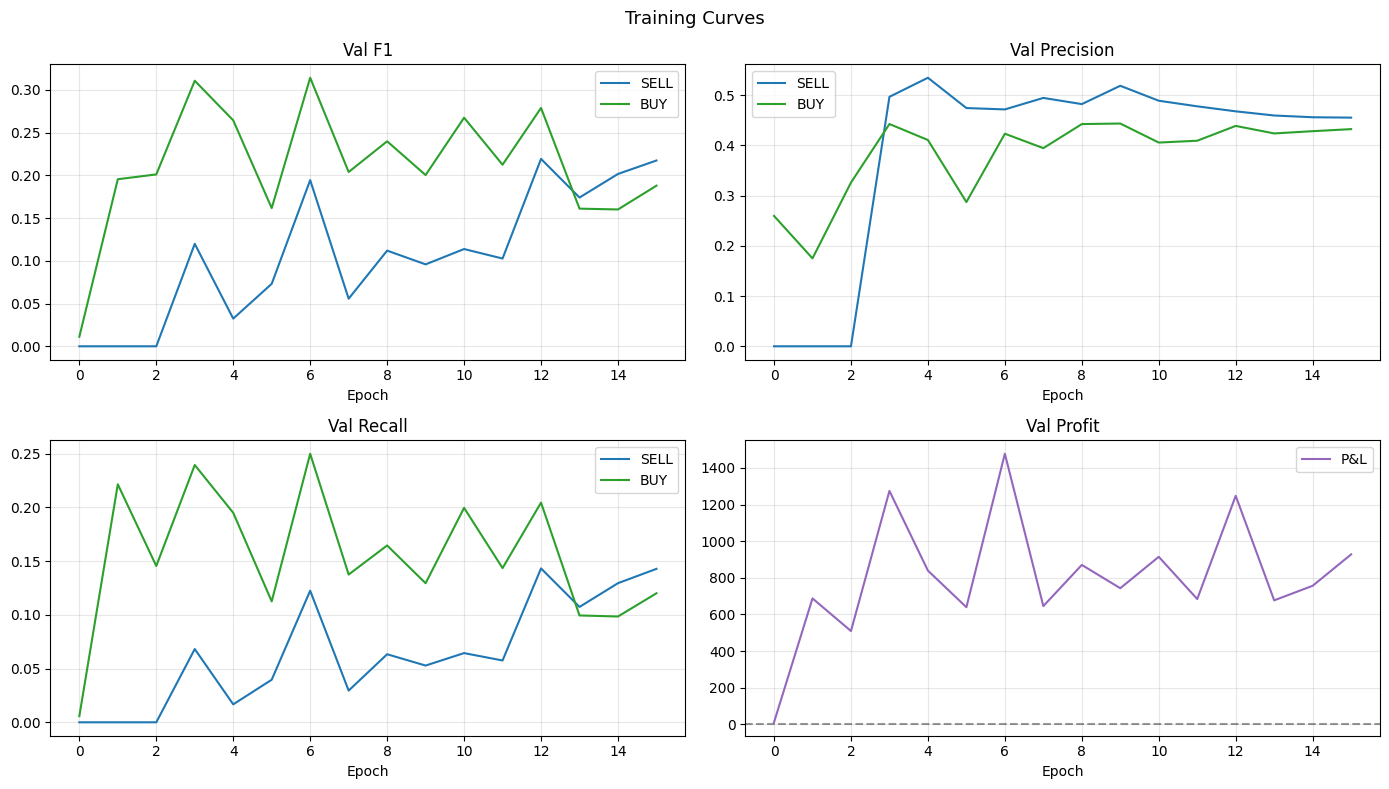

In [5]:
# Plot training metric curves from pack
m = pack.get('val_metrics', {})
if m:
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle('Training Curves', fontsize=13)

    axes[0, 0].plot(m.get('f1_sell_curve', []),        color='tab:blue',   label='SELL')
    axes[0, 0].plot(m.get('f1_buy_curve',  []),        color='tab:green',  label='BUY')
    axes[0, 0].set_title('Val F1'); axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

    axes[0, 1].plot(m.get('precision_sell_curve', []), color='tab:blue',   label='SELL')
    axes[0, 1].plot(m.get('precision_buy_curve',  []), color='tab:green',  label='BUY')
    axes[0, 1].set_title('Val Precision'); axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3)

    axes[1, 0].plot(m.get('recall_sell_curve', []),    color='tab:blue',   label='SELL')
    axes[1, 0].plot(m.get('recall_buy_curve',  []),    color='tab:green',  label='BUY')
    axes[1, 0].set_title('Val Recall'); axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3)

    axes[1, 1].plot(m.get('pnl_curve', []),            color='tab:purple', label='P&L')
    axes[1, 1].axhline(0, color='black', ls='--', alpha=0.4)
    axes[1, 1].set_title('Val Profit'); axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3)

    for ax in axes.flat:
        ax.set_xlabel('Epoch')

    plt.tight_layout()
    plt.show()
else:
    print("No training metrics found in pack.")

## Load Validation Dataset

In [6]:
df_raw = pd.read_csv(DS_NAME)
df_raw = df_raw.sort_values('Time').reset_index(drop=True)
df_raw['Time'] = pd.to_datetime(df_raw['Time'])

if EVAL_START:
    df_raw = df_raw[df_raw['Time'] >= EVAL_START]
if EVAL_END:
    df_raw = df_raw[df_raw['Time'] <= EVAL_END]

df_raw = df_raw.reset_index(drop=True)
print(f"Evaluation window: {df_raw['Time'].iloc[0]}  ->  {df_raw['Time'].iloc[-1]}")
print(f"Total bars: {len(df_raw):,}")
df_raw.tail(3)

Evaluation window: 2026-01-01 23:00:00+00:00  ->  2026-02-25 04:03:00+00:00
Total bars: 52,051


,Time,Open,High,Low,Close,Volume
52048,2026-02-25 04:01:00+00:00,6897.2,6897.2,6895.3,6895.8,91
52049,2026-02-25 04:02:00+00:00,6895.7,6896.1,6894.3,6894.8,85
52050,2026-02-25 04:03:00+00:00,6894.6,6895.3,6894.3,6894.4,94


## Features & Preprocessing

Applies the exact same feature engineering and scaling pipeline that was used during training,
loaded directly from the model pack.

In [7]:
def _prepare_features(df: pd.DataFrame, pack: dict) -> tuple:
    """Add features and scale using the saved pipeline from the model pack."""
    feature_fn    = pack['feature_function']
    preprocess_fn = pack['preprocess_function']
    preprocess_args = {**pack['preprocess_args'], 'target_col': None, 'outcomes_col': None}
    scaler = pack['scaler']

    df_feat = feature_fn(df.copy(), regime_params=pack.get('regime_params'))
    df_feat = df_feat.dropna().reset_index(drop=True)

    X, _, _, _, _, df_out = preprocess_fn(df_feat, scaler=scaler, return_df=True, **preprocess_args)
    X = np.ascontiguousarray(X)
    return X, df_feat, df_out

print("Building feature matrix...")
X, df_feat, _ = _prepare_features(df_raw, pack)
print(f"  Feature matrix: {X.shape}")

Building feature matrix...
  Feature matrix: (51235, 89)


## Batch Predictions

Sweeps the full evaluation period using a sliding window equal to `seq_len`.
The 3-class softmax output gives `[sell_prob, flat_prob, buy_prob]` for every bar.

Signals are emitted when `sell_prob >= SELL_THRESHOLD` or `buy_prob >= BUY_THRESHOLD`.
When both exceed their thresholds simultaneously, the higher probability wins.

In [8]:
def _batch_predict(model, X, seq_len, batch_size=2048):
    """Sliding-window batch inference.
    Returns (sell_probs, flat_probs, buy_probs) each of length N - seq_len."""
    N = len(X)
    n_windows = N - seq_len
    if n_windows <= 0:
        raise ValueError(f"Feature matrix too short ({N} rows) for seq_len={seq_len}")

    seqs = np.stack([X[i:i + seq_len] for i in range(n_windows)])  # (n, seq_len, F)
    sell_probs = np.zeros(n_windows, dtype=np.float32)
    flat_probs = np.zeros(n_windows, dtype=np.float32)
    buy_probs  = np.zeros(n_windows, dtype=np.float32)

    model.eval()
    with torch.no_grad():
        for start in range(0, n_windows, batch_size):
            batch  = torch.tensor(seqs[start:start + batch_size], dtype=torch.float32).to(device)
            logits = model(batch)
            probs  = torch.softmax(logits, dim=1).cpu().numpy()
            sell_probs[start:start + len(probs)] = probs[:, 0]
            flat_probs[start:start + len(probs)] = probs[:, 1]
            buy_probs[start:start + len(probs)]  = probs[:, 2]

    return sell_probs, flat_probs, buy_probs

seq_len = int(pack['model_info']['seq_len'])
print(f"Running model (seq_len={seq_len}, {len(X):,} rows)...")
sell_probs, flat_probs, buy_probs = _batch_predict(model, X, seq_len, PRED_BATCH)

# Each prediction aligns to df_feat.iloc[seq_len:]
pred_times = df_feat['Time'].iloc[seq_len:].reset_index(drop=True)

preds = pd.DataFrame({
    'Time':      pred_times,
    'sell_prob': sell_probs,
    'flat_prob': flat_probs,
    'buy_prob':  buy_probs,
})

# Raw signals using configured thresholds
preds['raw_signal'] = 0
preds.loc[preds['buy_prob']  >= BUY_THRESHOLD,  'raw_signal'] =  1
preds.loc[preds['sell_prob'] >= SELL_THRESHOLD, 'raw_signal'] = -1
# Resolve conflicts: higher probability wins
both = (preds['buy_prob'] >= BUY_THRESHOLD) & (preds['sell_prob'] >= SELL_THRESHOLD)
preds.loc[both & (preds['buy_prob'] >= preds['sell_prob']), 'raw_signal'] =  1
preds.loc[both & (preds['sell_prob'] >  preds['buy_prob']), 'raw_signal'] = -1

# Session gate
if TRADING_HOURS is not None:
    t_start    = pd.to_datetime(TRADING_HOURS[0]).time()
    t_end      = pd.to_datetime(TRADING_HOURS[1]).time()
    in_session = preds['Time'].dt.time.between(t_start, t_end, inclusive='left')
    preds.loc[~in_session, 'raw_signal'] = 0
    print(f"Session gate: {(~in_session).sum():,} bars forced to HOLD")

print(f"\nPrediction rows: {len(preds):,}")
print("Raw signal distribution:")
print(preds['raw_signal'].value_counts().rename({-1:'SELL', 0:'HOLD', 1:'BUY'}))

Running model (seq_len=512, 51,235 rows)...

Prediction rows: 50,723
Raw signal distribution:
raw_signal
HOLD    50613
SELL       68
BUY        42
Name: count, dtype: int64


In [9]:
# Signal Confidence Distribution
n_buy  = (preds['raw_signal'] ==  1).sum()
n_sell = (preds['raw_signal'] == -1).sum()
n_hold = (preds['raw_signal'] ==  0).sum()
bins   = dict(start=0, end=1, size=0.025)

fig = make_subplots(rows=1, cols=3,
    subplot_titles=(
        f'SELL prob  (signals: {n_sell:,})',
        f'BUY prob   (signals: {n_buy:,})',
        f'SELL vs BUY   [S:{n_sell:,} B:{n_buy:,} H:{n_hold:,}]',
    ),
    horizontal_spacing=0.08,
)

fig.add_trace(go.Histogram(x=preds['sell_prob'], xbins=bins,
    marker_color='tomato', opacity=0.85, name='SELL', showlegend=False), row=1, col=1)
fig.add_vline(x=SELL_THRESHOLD, line=dict(color='red', dash='dash', width=1.5),
    annotation_text=f'Thresh {SELL_THRESHOLD}', annotation_position='top right', row=1, col=1)

fig.add_trace(go.Histogram(x=preds['buy_prob'], xbins=bins,
    marker_color='steelblue', opacity=0.85, name='BUY', showlegend=False), row=1, col=2)
fig.add_vline(x=BUY_THRESHOLD, line=dict(color='blue', dash='dash', width=1.5),
    annotation_text=f'Thresh {BUY_THRESHOLD}', annotation_position='top right', row=1, col=2)

colour_map = {1: 'steelblue', -1: 'tomato', 0: 'lightgrey'}
label_map  = {1: 'BUY',       -1: 'SELL',   0: 'HOLD'}
for sig_val in [0, 1, -1]:
    mask = preds['raw_signal'] == sig_val
    fig.add_trace(go.Scattergl(
        x=preds.loc[mask, 'buy_prob'], y=preds.loc[mask, 'sell_prob'],
        mode='markers', marker=dict(color=colour_map[sig_val], size=3, opacity=0.35),
        name=label_map[sig_val]), row=1, col=3)

fig.add_vline(x=BUY_THRESHOLD,  line=dict(color='steelblue', dash='dash', width=1), row=1, col=3)
fig.add_hline(y=SELL_THRESHOLD, line=dict(color='tomato',    dash='dash', width=1), row=1, col=3)

fig.update_layout(title_text='Signal Confidence Distribution', title_font_size=14,
                  height=420, bargap=0.05,
                  legend=dict(orientation='h', yanchor='bottom', y=1.08, xanchor='right', x=1))
fig.update_xaxes(title_text='Probability', row=1, col=1)
fig.update_xaxes(title_text='Probability', row=1, col=2)
fig.update_xaxes(title_text='BUY P', row=1, col=3)
fig.update_yaxes(title_text='Bars',  row=1, col=1)
fig.update_yaxes(title_text='Bars',  row=1, col=2)
fig.update_yaxes(title_text='SELL P', row=1, col=3)
fig.show()

## Trade Gating

Sequential gates applied to raw signals. Signals failing any active gate are changed to **HOLD (0)**.

| Gate | Condition |
|---|---|
| **Regime** | BUY only during uptrend (`regime == 1`); SELL only during downtrend (`regime == -1`) |
| **Breakout** | BUY confirmed if next bar's high breaks above signal bar's high |
| **Donchian** | Optional trend confirmation from Donchian channel direction |

In [10]:
from Learn.labels import causal_market_regime
from Learn.features import donchian_trend

regime_params = pack.get('regime_params', {})
regime_df = causal_market_regime(df_raw.copy(), **regime_params)
df_raw['regime'] = regime_df.values
df_raw['donchian_trend'] = donchian_trend(df_raw, length=regime_params.get('atr_window', 14))

ohlc_cols = df_raw[['Time', 'Open', 'High', 'Low', 'Close', 'regime', 'donchian_trend']].copy()
df_gated  = pd.merge(preds, ohlc_cols, on='Time', how='left')

df_ohlc_next = df_raw[['Time', 'High', 'Low']].rename(
    columns={'High': 'next_high', 'Low': 'next_low'})
df_ohlc_next['Time'] = df_ohlc_next['Time'].shift(1)
df_gated = pd.merge(df_gated, df_ohlc_next, on='Time', how='left')
df_gated['signal'] = df_gated['raw_signal'].copy()

if GATE_REGIME:
    regime_buy_block  = (df_gated['signal'] ==  1) & (df_gated['regime'] != 1)
    regime_sell_block = (df_gated['signal'] == -1) & (df_gated['regime'] != -1)
    df_gated.loc[regime_buy_block | regime_sell_block, 'signal'] = 0
    print(f"Regime gate removed {(regime_buy_block | regime_sell_block).sum():,} signals")

if GATE_BREAKOUT:
    buy_no_break  = (df_gated['signal'] ==  1) & (df_gated['next_high'] <= df_gated['High'])
    sell_no_break = (df_gated['signal'] == -1) & (df_gated['next_low']  >= df_gated['Low'])
    df_gated.loc[buy_no_break | sell_no_break, 'signal'] = 0
    print(f"Breakout gate removed {(buy_no_break | sell_no_break).sum():,} signals")

if GATE_DONCHIAN:
    buy_no_don  = (df_gated['signal'] ==  1) & (df_gated['donchian_trend'] <= 0)
    sell_no_don = (df_gated['signal'] == -1) & (df_gated['donchian_trend'] >= 0)
    df_gated.loc[buy_no_don | sell_no_don, 'signal'] = 0
    print(f"Donchian gate removed {(buy_no_don | sell_no_don).sum():,} signals")

raw_counts  = df_gated['raw_signal'].value_counts().rename({-1:'SELL', 0:'HOLD', 1:'BUY'})
gate_counts = df_gated['signal'].value_counts().rename({-1:'SELL', 0:'HOLD', 1:'BUY'})
summary = pd.DataFrame({'Raw': raw_counts, 'Gated': gate_counts}).fillna(0).astype(int)
summary['Removed'] = summary['Raw'] - summary['Gated']
print(f"\n{summary.to_string()}")

Regime gate removed 16 signals
Breakout gate removed 57 signals
Donchian gate removed 9 signals

        Raw  Gated  Removed
HOLD  50613  50695      -82
SELL     68     18       50
BUY      42     10       32


## Candlestick Chart

Interactive OHLCV chart overlaid with gated trade signals.
Green triangles = BUY, red triangles = SELL.

In [16]:
df_chart = df_raw[['Time', 'Open', 'High', 'Low', 'Close', 'Volume']].copy()
sig_cols = ['Time', 'signal', 'buy_prob', 'sell_prob']
df_chart = df_chart.merge(df_gated[sig_cols], on='Time', how='left')
df_chart['signal'] = df_chart['signal'].fillna(0).astype(int)

buy_bars  = df_chart[df_chart['signal'] ==  1]
sell_bars = df_chart[df_chart['signal'] == -1]

atr_series = df_chart['High'].rolling(14).mean() - df_chart['Low'].rolling(14).mean()
offset     = float(atr_series.mean()) * 0.5

vol_colors = np.where(df_chart['Close'] >= df_chart['Open'], '#26a69a', '#ef5350')

fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                    row_heights=[0.8, 0.2], vertical_spacing=0.02)

fig.add_trace(go.Candlestick(
    x=df_chart['Time'], open=df_chart['Open'], high=df_chart['High'],
    low=df_chart['Low'], close=df_chart['Close'], name='OHLCV',
    increasing_line_color='#26a69a', decreasing_line_color='#ef5350',
    increasing_fillcolor='#26a69a', decreasing_fillcolor='#ef5350',
    line=dict(width=1), hoverinfo='skip'), row=1, col=1)

fig.add_trace(go.Scatter(
    x=buy_bars['Time'], y=buy_bars['Low'] - offset, mode='markers',
    marker=dict(symbol='triangle-up', size=9, color='#00e676',
                line=dict(color='darkgreen', width=0.8)),
    name='BUY signal', hoverinfo='skip'), row=1, col=1)

fig.add_trace(go.Scatter(
    x=sell_bars['Time'], y=sell_bars['High'] + offset, mode='markers',
    marker=dict(symbol='triangle-down', size=9, color='#ff1744',
                line=dict(color='darkred', width=0.8)),
    name='SELL signal', hoverinfo='skip'), row=1, col=1)

fig.add_trace(go.Bar(x=df_chart['Time'], y=df_chart['Volume'],
    marker_color=vol_colors, marker_line_width=0,
    name='Volume', hoverinfo='skip', showlegend=False), row=2, col=1)

fig.update_layout(
    xaxis=dict(rangeslider=dict(visible=False),
               rangeselector=dict(buttons=[
                   dict(count=1, label='1d', step='day', stepmode='backward'),
                   dict(count=7, label='1w', step='day', stepmode='backward'),
                   dict(count=1, label='1mo', step='month', stepmode='backward'),
                   dict(count=3, label='3mo', step='month', stepmode='backward'),
                   dict(step='all', label='All'),
               ]), type='date'),
    xaxis2=dict(title='Time'),
    yaxis=dict(title='Price', fixedrange=False),
    yaxis2=dict(title='Volume', fixedrange=True),
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    height=1200, margin=dict(l=60, r=20, t=80, b=60), hovermode=False,
    paper_bgcolor='#1e1e1e', plot_bgcolor='#1e1e1e', font=dict(color='#d4d4d4'),
    xaxis_gridcolor='#333', yaxis_gridcolor='#333',
    xaxis2_gridcolor='#333', yaxis2_gridcolor='#333',
)
fig.show()

## P&L Analysis

Simulates each gated trade signal against actual forward price action using ATR-based TP/SL
from the model pack's `outcome_params`. Commission is deducted from every trade.

In [12]:
from Learn.labels import calculate_trade_outcomes_all_candles
import talib

outcome_params  = pack.get('outcome_params', {})
atr_window  = outcome_params.get('atr_window', 14)
tp_mult     = outcome_params.get('tp_mult', 2.5)
sl_mult     = outcome_params.get('sl_mult', 2.5)
max_horizon = outcome_params.get('max_horizon', 60)
pip_value_per_lot = PIP_VALUE_USD * LOT_SIZE

print(f"Outcome params: ATR={atr_window} | TP={tp_mult}xATR | SL={sl_mult}xATR | Horizon={max_horizon}")
print(f"Fee: ${COMMISSION_USD:.2f} r/t | Lot: {LOT_SIZE} | Pip value: ${pip_value_per_lot:.2f}/pip")

df_sim = df_raw.copy().reset_index(drop=True)
print("Computing trade outcomes...")
outcomes_table = calculate_trade_outcomes_all_candles(
    df_sim, atr_window=atr_window, tp_mult=tp_mult, sl_mult=sl_mult, max_horizon=max_horizon)
df_sim['buy_outcome']     = outcomes_table['buy_outcome'].values
df_sim['sell_outcome']    = outcomes_table['sell_outcome'].values
df_sim['buy_exit_price']  = outcomes_table['buy_exit_price'].values
df_sim['sell_exit_price'] = outcomes_table['sell_exit_price'].values
df_sim['atr'] = talib.ATR(df_sim['High'], df_sim['Low'], df_sim['Close'], timeperiod=atr_window)

time_to_idx = {t: i for i, t in enumerate(df_sim['Time'])}

def _simulate_trade(signal_time, direction):
    idx = time_to_idx.get(signal_time)
    if idx is None:
        return None
    row = df_sim.iloc[idx]
    atr = row['atr']
    if pd.isna(atr):
        return None
    if direction == 1:
        entry, tp, sl = row['High'], row['High'] + atr * tp_mult, row['High'] - atr * sl_mult
        raw_outcome, exit_price = row['buy_outcome'], row['buy_exit_price']
    else:
        entry, tp, sl = row['Low'], row['Low'] - atr * tp_mult, row['Low'] + atr * sl_mult
        raw_outcome, exit_price = row['sell_outcome'], row['sell_exit_price']
    if pd.isna(raw_outcome) or pd.isna(exit_price):
        return None

    outcome = 'tp' if raw_outcome == 1.0 else ('sl' if raw_outcome == -1.0 else 'timeout')
    raw_pips = direction * (exit_price - entry) / PIP_SIZE
    raw_usd  = raw_pips * pip_value_per_lot
    net_usd  = raw_usd - COMMISSION_USD

    sig_row = df_gated[df_gated['Time'] == signal_time]
    return {
        'time':       signal_time,
        'direction':  'BUY' if direction == 1 else 'SELL',
        'entry':      round(entry, 5),
        'tp':         round(tp, 5),
        'sl':         round(sl, 5),
        'exit_price': round(exit_price, 5),
        'atr_pips':   round(atr / PIP_SIZE, 2),
        'outcome':    outcome,
        'raw_pips':   round(raw_pips, 2),
        'raw_usd':    round(raw_usd, 2),
        'net_usd':    round(net_usd, 2),
        'buy_prob':   float(sig_row['buy_prob'].iloc[0])  if direction ==  1 and len(sig_row) else None,
        'sell_prob':  float(sig_row['sell_prob'].iloc[0]) if direction == -1 and len(sig_row) else None,
    }

trades_raw = []
signal_bars = df_gated[df_gated['signal'] != 0]
for _, row in signal_bars.iterrows():
    result = _simulate_trade(row['Time'], int(row['signal']))
    if result:
        trades_raw.append(result)

trades = pd.DataFrame(trades_raw)
print(f"\n{'─'*50}")
print(f"  Total trades simulated: {len(trades):,}")
if len(trades):
    tp_count = (trades['outcome'] == 'tp').sum()
    sl_count = (trades['outcome'] == 'sl').sum()
    to_count = (trades['outcome'] == 'timeout').sum()
    net_total = trades['net_usd'].sum()
    print(f"  TP: {tp_count} | SL: {sl_count} | Timeout: {to_count}")
    print(f"  Win rate:    {tp_count/len(trades)*100:.1f}%")
    print(f"  Net P&L:     ${net_total:+,.2f}")
    print(f"  Avg / trade: ${trades['net_usd'].mean():+.2f}")

Outcome params: ATR=14 | TP=2.5xATR | SL=2.5xATR | Horizon=1000
Fee: $0.00 r/t | Lot: 1.0 | Pip value: $10.00/pip
Computing trade outcomes...

──────────────────────────────────────────────────
  Total trades simulated: 28
  TP: 20 | SL: 8 | Timeout: 0
  Win rate:    71.4%
  Net P&L:     $+5,779,860.56
  Avg / trade: $+206423.59


,Trades,TP,SL,Timeout,Win Rate %,Net USD ($),Avg USD ($),Best Trade ($),Worst Trade ($),Commission ($)
ALL,28.0,20.0,8.0,0.0,71.4,5779860.56,206423.59,1073895.77,-1088260.36,0.0
BUY,10.0,8.0,2.0,0.0,80.0,2190243.39,219024.34,732216.96,-509252.23,0.0
SELL,18.0,12.0,6.0,0.0,66.7,3589617.17,199423.18,1073895.77,-1088260.36,0.0


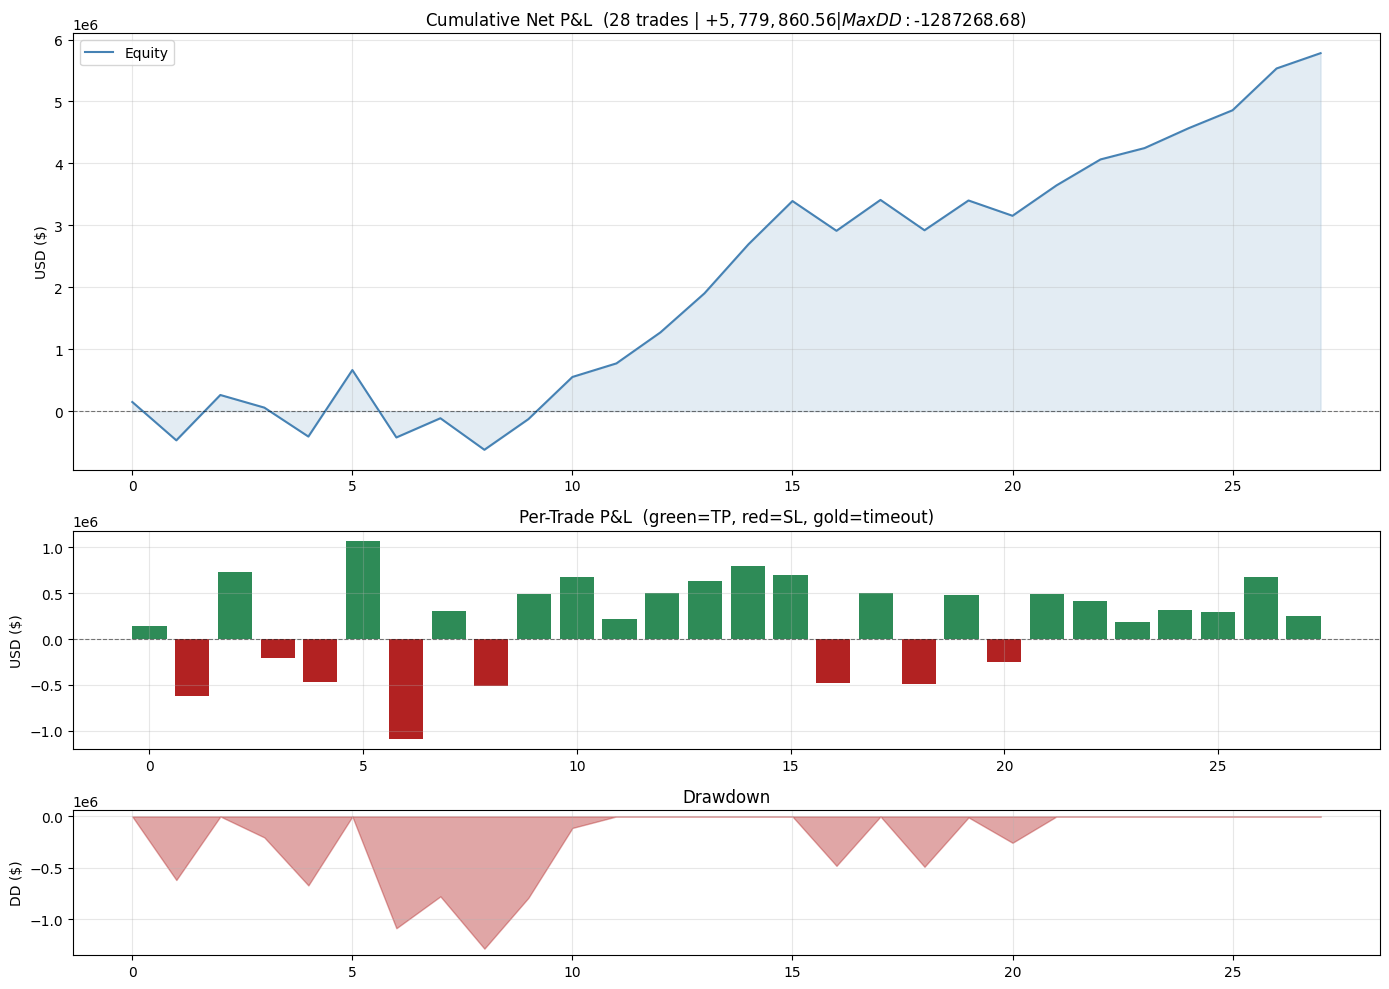

In [13]:
if len(trades) == 0:
    print("No trades to display.")
else:
    def _summary_stats(df):
        if len(df) == 0:
            return {}
        return {
            'Trades':          len(df),
            'TP':              (df['outcome'] == 'tp').sum(),
            'SL':              (df['outcome'] == 'sl').sum(),
            'Timeout':         (df['outcome'] == 'timeout').sum(),
            'Win Rate %':      round((df['outcome'] == 'tp').mean() * 100, 1),
            'Net USD ($)':     round(df['net_usd'].sum(), 2),
            'Avg USD ($)':     round(df['net_usd'].mean(), 2),
            'Best Trade ($)':  round(df['net_usd'].max(), 2),
            'Worst Trade ($)': round(df['net_usd'].min(), 2),
            'Commission ($)':  round(COMMISSION_USD * len(df), 2),
        }

    stats = pd.DataFrame({
        'ALL':  _summary_stats(trades),
        'BUY':  _summary_stats(trades[trades['direction'] == 'BUY']),
        'SELL': _summary_stats(trades[trades['direction'] == 'SELL']),
    }).T
    display(stats)

    trades_sorted = trades.sort_values('time').reset_index(drop=True)
    trades_sorted['cum_usd'] = trades_sorted['net_usd'].cumsum()
    running_max = trades_sorted['cum_usd'].cummax()
    drawdown    = trades_sorted['cum_usd'] - running_max
    max_dd      = drawdown.min()

    fig, axes = plt.subplots(3, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1.5, 1]})

    axes[0].plot(trades_sorted.index, trades_sorted['cum_usd'], color='steelblue', lw=1.5, label='Equity')
    axes[0].fill_between(trades_sorted.index, trades_sorted['cum_usd'], alpha=0.15, color='steelblue')
    axes[0].axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
    axes[0].set_title(
        f'Cumulative Net P&L  ({len(trades):,} trades | ${trades_sorted["cum_usd"].iloc[-1]:+,.2f} | MaxDD: ${max_dd:.2f})')
    axes[0].set_ylabel('USD ($)'); axes[0].grid(alpha=0.3); axes[0].legend()

    colours = trades_sorted['outcome'].map({'tp': 'seagreen', 'sl': 'firebrick', 'timeout': 'goldenrod'})
    axes[1].bar(trades_sorted.index, trades_sorted['net_usd'], color=colours, width=0.8)
    axes[1].axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
    axes[1].set_ylabel('USD ($)')
    axes[1].set_title('Per-Trade P&L  (green=TP, red=SL, gold=timeout)')
    axes[1].grid(alpha=0.3)

    axes[2].fill_between(trades_sorted.index, drawdown, 0, color='firebrick', alpha=0.4)
    axes[2].set_ylabel('DD ($)'); axes[2].set_title('Drawdown'); axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

## Model Insights

### Threshold Sweep
Sweeps both BUY and SELL thresholds from 0.30 → 0.95, reporting trade count, win rate, and net P&L at each level.

### Probability Calibration
Histograms of model output probabilities split by actual trade outcome (TP / SL / timeout) — a well-calibrated model should show TP trades concentrated at higher confidence.

### Gating Effectiveness
Compares raw-signal vs fully-gated win rates to quantify the marginal value of the regime, breakout, and Donchian gates.

,trades,win_pct,net_usd,avg_usd
threshold,,,,
0.30,0,0.0,0.0,0.0
0.35,0,0.0,0.0,0.0
0.40,0,0.0,0.0,0.0
0.45,0,0.0,0.0,0.0
0.50,0,0.0,0.0,0.0
0.55,0,0.0,0.0,0.0
0.60,0,0.0,0.0,0.0
0.65,0,0.0,0.0,0.0
0.70,0,0.0,0.0,0.0


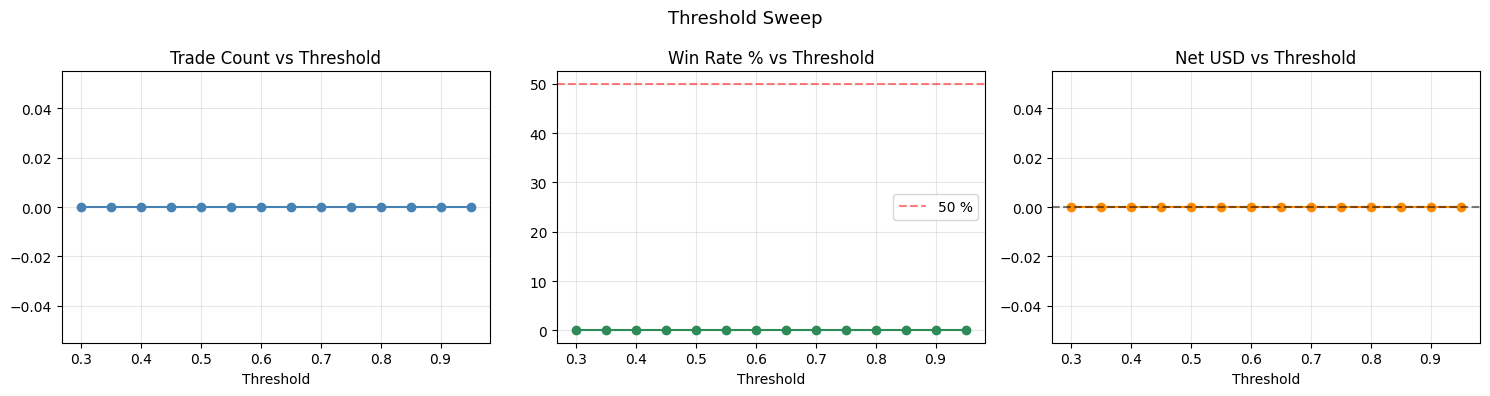

In [14]:
if len(trades) == 0:
    print("No trades available for threshold sweep.")
else:
    thresholds = np.arange(0.30, 0.96, 0.05)
    sweep_rows = []

    for thresh in thresholds:
        sig = np.zeros(len(df_gated), dtype=int)
        buy_mask  = df_gated['buy_prob'].values  >= thresh
        sell_mask = df_gated['sell_prob'].values >= thresh
        conflict  = buy_mask & sell_mask

        sig[buy_mask]  =  1
        sig[sell_mask] = -1
        # Resolve conflicts: favour the higher probability
        sig[conflict & (df_gated['buy_prob'].values >= df_gated['sell_prob'].values)] =  1
        sig[conflict & (df_gated['sell_prob'].values > df_gated['buy_prob'].values)]  = -1

        if GATE_REGIME:
            sig[(sig ==  1) & (df_gated['regime'].values !=  1)] = 0
            sig[(sig == -1) & (df_gated['regime'].values != -1)] = 0
        if GATE_BREAKOUT:
            sig[(sig ==  1) & (df_gated['next_high'].values <= df_gated['High'].values)] = 0
            sig[(sig == -1) & (df_gated['next_low'].values  >= df_gated['Low'].values)]  = 0

        t_list = []
        mask_idx = np.where(sig != 0)[0]
        for idx in mask_idx:
            r = _simulate_trade(pd.Timestamp(df_gated['Time'].values[idx]), int(sig[idx]))
            if r:
                t_list.append(r)

        if not t_list:
            sweep_rows.append({'threshold': round(thresh, 2), 'trades': 0,
                               'win_pct': 0.0, 'net_usd': 0.0, 'avg_usd': 0.0})
            continue

        t_df = pd.DataFrame(t_list)
        sweep_rows.append({
            'threshold': round(thresh, 2),
            'trades':    len(t_df),
            'win_pct':   round((t_df['outcome'] == 'tp').mean() * 100, 1),
            'net_usd':   round(t_df['net_usd'].sum(), 2),
            'avg_usd':   round(t_df['net_usd'].mean(), 2),
        })

    sweep_df = pd.DataFrame(sweep_rows)
    display(sweep_df.set_index('threshold'))

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(sweep_df['threshold'], sweep_df['trades'],  marker='o', color='steelblue')
    axes[0].set_title('Trade Count vs Threshold'); axes[0].set_xlabel('Threshold'); axes[0].grid(alpha=0.3)

    axes[1].plot(sweep_df['threshold'], sweep_df['win_pct'], marker='o', color='seagreen')
    axes[1].axhline(50, color='red', ls='--', alpha=0.5, label='50 %')
    axes[1].set_title('Win Rate % vs Threshold'); axes[1].set_xlabel('Threshold')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    axes[2].plot(sweep_df['threshold'], sweep_df['net_usd'], marker='o', color='darkorange')
    axes[2].axhline(0, color='black', ls='--', alpha=0.5)
    axes[2].set_title('Net USD vs Threshold'); axes[2].set_xlabel('Threshold'); axes[2].grid(alpha=0.3)

    plt.suptitle('Threshold Sweep', fontsize=13)
    plt.tight_layout()
    plt.show()

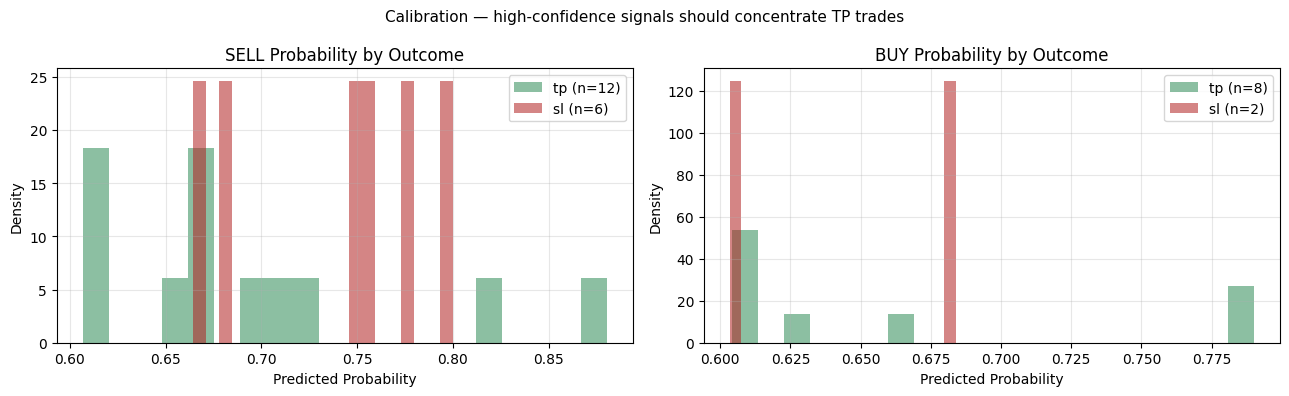


Gating Effectiveness (win rate %):


,Trades,Win Rate %
Scenario,,
Raw (no gating),0,0.0
Fully gated,0,0.0


In [15]:
# ── Probability Calibration ──────────────────────────────────────────────────
if len(trades) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for ax, col, title in [
        (axes[0], 'sell_prob', 'SELL Probability by Outcome'),
        (axes[1], 'buy_prob',  'BUY Probability by Outcome'),
    ]:
        subset = trades[trades[col].notna()]
        if subset.empty:
            ax.set_visible(False)
            continue
        for outcome, color in [('tp', 'seagreen'), ('sl', 'firebrick'), ('timeout', 'goldenrod')]:
            vals = subset.loc[subset['outcome'] == outcome, col].dropna()
            if len(vals):
                ax.hist(vals, bins=20, alpha=0.55, color=color,
                        label=f'{outcome} (n={len(vals)})', density=True)
        ax.set_title(title)
        ax.set_xlabel('Predicted Probability')
        ax.set_ylabel('Density')
        ax.legend(); ax.grid(alpha=0.3)
    plt.suptitle('Calibration — high-confidence signals should concentrate TP trades', fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print("No trades — skipping calibration plot.")

# ── Gating Effectiveness ──────────────────────────────────────────────────────
print("\nGating Effectiveness (win rate %):")

def _eval_signals(sig_array):
    """Run simulation for a given signal array over df_gated; return (n_trades, win_pct)."""
    results = []
    for idx in np.where(sig_array != 0)[0]:
        r = _simulate_trade(pd.Timestamp(df_gated['Time'].values[idx]), int(sig_array[idx]))
        if r:
            results.append(r)
    if not results:
        return 0, 0.0
    t = pd.DataFrame(results)
    return len(t), round((t['outcome'] == 'tp').mean() * 100, 1)

# Raw signal (before any gating)
raw_sig = np.zeros(len(df_gated), dtype=int)
raw_sig[df_gated['buy_prob'].values  >= BUY_THRESHOLD]  =  1
raw_sig[df_gated['sell_prob'].values >= SELL_THRESHOLD] = -1
conflict = (df_gated['buy_prob'].values >= BUY_THRESHOLD) & (df_gated['sell_prob'].values >= SELL_THRESHOLD)
raw_sig[conflict & (df_gated['buy_prob'].values >= df_gated['sell_prob'].values)] =  1
raw_sig[conflict & (df_gated['sell_prob'].values > df_gated['buy_prob'].values)]  = -1

gated_sig = df_gated['signal'].values.astype(int)

n_raw,   wr_raw   = _eval_signals(raw_sig)
n_gated, wr_gated = _eval_signals(gated_sig)

gate_summary = pd.DataFrame({
    'Scenario':   ['Raw (no gating)', 'Fully gated'],
    'Trades':     [n_raw, n_gated],
    'Win Rate %': [wr_raw, wr_gated],
})
display(gate_summary.set_index('Scenario'))